# General template

This Jupyter notebook is a template for a pipeline that can be used to analyse, clean, and extract basic features from smartphone and wearables data. It has been designed to be applicable to a variety of data types (e.g. `step count`, `heart rate`, `screen use`), and is intended to be applied to a set of data files of one specific type of data at a time. The following assumptions are made about the dataset:

:::{note} Key Assumptions
1. All data is stored in a single file for each participant.
2. All data files belonging to this data type have the same name (e.g. `sensorkit_device_usage`), the variable `csv_name` below will be set to this name.
3. There is a `timestamp` field in each file that gives the time of each datapoint and the name of the timestamp field is the same across all files.
4. There are one or more `measurement` fields in each csv that give measured values such as number of steps, heart rate, sleep stage type, etc. The names of these measurement fields are consistent across all files.
5. There is either a `duration` field, an `end time` field, or neither of these. There should not be both. If there is a duration field it should be in `seconds`. The name of the duration or end time field should be consistent across all files.
6. All time columns are in `unix seconds`. If they are not currently in this format, all the functions in this pipeline that require the time columns to be in unix seconds have an optional variable `convert_to_unix` that can be set to a list of all columns that need converting to unix. However, this does not currently support all time formats and also rounds to the nearest second, so it may be necessary to convert time columns to unix seconds before using this template.
7. The data is read from an input folder (assigned below) which contains one of two possible folder structures. Folder structure 1: the input folder contains subfolders for each site, each site subfolder contains subfolders for each participant, and each participant subfolder has subfolders for each data type that is available for that participant. In each data type subfolder, the data file is stored as a csv compressed Gzip file. Example:
```
input/
├── site_A/
│   ├── participant_01/
│   │   ├── sensorkit_device_usage/
│   │   │   └── sensorkit_device_usage.csv.gz
│   │   └── active_apple_healthkit_steps/
│   │       └── active_apple_healthkit_steps.csv.gz
│   └── participant_02/
│       ├── sensorkit_device_usage/
│       │   └── sensorkit_device_usage.csv.gz
│       └── active_apple_healthkit_steps/
│           └── active_apple_healthkit_steps.csv.gz
└── site_B/
    └── participant_03/
        └── sensorkit_device_usage/
            └── sensorkit_device_usage.csv.gz
```

Folder structure 2: the input folder contains subfolders for each site, each site subfolder contains subfolders for each participant, each participant folder contains all the data files for that participant as csv files. Example:
```
input/
├── site_A/
│   ├── participant_01/
│   │   ├── sensorkit_device_usage.csv
│   │   └── active_apple_healthkit_steps.csv
│   └── participant_02/
│       ├── sensorkit_device_usage.csv
│       └── active_apple_healthkit_steps.csv
└── site_B/
    └── participant_03/
        └── sensorkit_device_usage.csv
```
:::

There are two sections to this template. The first, {ref}`data analysis <data-analysis>` uses a series of functions to analyse the data, including three main functions that give a general overview of the `sampling frequency`, `distribution of values`, and `frequency of timestamp-related errors`. These three main functions are likely to be neccesary for all data types. There are also additional functions for analysis tasks that are only needed for specific types of data, we will give examples of these being used in the {doc}`step count <steps_specific_template>`,
{doc}`sleep <sleep_specific_template>`, and
{doc}`heart rate <heart_rate_specific_template>` templates.

The second section, {ref}`data cleaning and feature extraction<data-cleaning>`, uses information gained from the first section to produce a cleaned version of the data and extract features reporting meta data (e.g. total datapoints) and basic summarisation features (e.g. average heart rate, total number of steps).

All functions can be further tailored to your data in two ways:

```{note} Functions
- **Filtering the data files.** In each function, after the data file is read in to a pandas dataframe the function `df_filter` in `helper_funcs.py` is used to filter out any unwanted rows if the optional variable `filter_dict` is not None (the default). For example, there may be multiple data types in the file and you want to only select rows that have the correct value in a data type column, or there may be data from multiple devices (e.g. watch and phone) and you just want to analyse/extract features from one type of device. To filter the data, you need to define a dictionary of column names and allowed values and set `filter_dict` to this dictionary. A template dictionary to edit (if filtering is required, it can be ignored otherwise) is given in each of the code snippets below before each function is called, and the below sections will include examples of using this filtering option.
- **Specific adjustments to the data.** In each of the three main data analysis functions, a function `df_adjustment` is called after `df_filter` to make any specific adjustments to the data before it is analysed if the optional variable `df_adjustment_args` is not [None] (the default), for example, constructing a new column out of the existing columns. This function has been included to make this template easily extendable, you can add new lines of code to the function to create additional options for adjusting specific data types. There are three versions of `df_adjustment` for each of the three main data analysis functions, which are each in separate files (the files ending with `df_adjustment.py`). Some examples of `df_adjustment` being used are shown in the steps specific template. To call `df_adjustment`, the variable `df_adjustment_args` needs to be changed from the default [None] to a list. The first item should be a string for a key word for that adjustment and the rest of the items should be specific variables required for that adjustment.
```

(data-analysis)=
## Data analysis

In this section we will describe how to use the three main data analysis
functions. The data type `sensorkit_device_usage` will be used as an example,
this gives information about how much the participants interact with their
devices. First, we import all necessary functions and methods for this analysis and get a list of the
file paths:

In [7]:
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import HTML, display

sys.path.insert(
    0, str(Path().resolve().parent / "src")
)  # Set the path to the src folder so that we can import the functions from there

import all_field_summaries
import calculate_durations
import clean_and_extract_features
import feature_extraction
import helper_funcs as helper_funcs
import timestamps_check

base_dir = Path.cwd().parent  # go up one level from where you're running
folder_path = base_dir / "example_data"
folder_path_str = str(folder_path) + "/"

# Set input variables
Folder_structure = 1  # This should be either 1 or 2 (see above)
csv_name = (
    "sensorkit_device_usage"  # The standard name for the csv that contains this data
)
site_list = ["test"]  # The names of the subfolders for each site
input_folder = folder_path_str  # The folder that contains all the site subfolders

# Get a list of the paths to each file to be included in this analysis
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure, site_list
)

4 files found


### Summarise Fields

The purpose of this function is to get a general idea of the distribution of values in any fields of interest across all the data. This is likely to include measurement fields to check whether the measured values generally seem sensible. It may also include any other fields you wish to analyse, for example you might want to check that a field reporting a measurement unit gives a consistent value.

```{tip}
If there are less than 15 unique values in a field these will be listed,
otherwise the number of unique values will be given. For numerical fields,
`mean`, `median`, `range`, `IQR`, and `1st` and `99th percentiles` are also
reported.
```

When analysing each field, the timestamp column is used to remove repeated values that occur at the same time. Different values at the same time are not removed as this analysis is intended to show the full spread of possible values rather than give a fully accurate description of the distribution, however, if required, adjustments can be made in the `df_adjustment` function.

Below is an example of this tool being run on `sensorkit_device` usage data. To tailor this to another data type, adjust the following variables:

```{note} Variables
- `fields`: should be a list of the names of any fields you want to analyse.
- `time_stamp`: name of the timestamp column. This will be the start time column if there is also an end time column.
- `df_adjustment_args`: optional, default is None, this only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```

In [8]:
# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

# Call Summarise_fields
df = all_field_summaries.Summarise_fields(
    files_list=files_list,
    fields=[
        "value.device",
        "value.totalUnlockDuration",
        "value.totalUnlocks",
    ],  # The fields to be analysed.
    time_stamp="value.time",  # The name of the column that contains the timestamp.
    filter_dict=None,  # No fields need filtering so this has been left as None.
    df_adjustment_args=[None],  # No adjustments necessary for this data type.
)

# Display the results
df = df.round(
    2
)  # Rounds the numbers for ease of viewing, may need to be adjusted depending on data.
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:12px'>{html_table}</div>"
display(HTML(styled_html))

Field,Total,Values,Mean,Min,P1,LQT,median,UQT,P99,Max
value.device,6641,"{'Apple Watch': 921, 'iPhone': 5720}",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A
value.totalUnlockDuration,6641,"Too big, 420 unique values",144.658184,0.0,0.0,0.0,0.0,30.0,900.0,900.0
value.totalUnlocks,6641,"Too big, 26 unique values",0.714049,0,0,0,0,0,11,26


In this sensorkit device usage example we have used this function to investigate
two measurement columns (`value.UnlockDuration` and `value.totalUnlocks`) and
one device column. The results can be used to check the distribution of values
for the two measurement columns so we can decide whether they seem sensible. For
this particular data type the measured values need to be considered in context
of the datapoint duration, the tool below shows this is always 900 seconds,
therefore the measured values look sensible. The results for the device column
show that two separate device types have been used. This means that we now have
to consider whether we want to use both devices or filter one out. For this
example, we have decided we are interested in phone data only. Therefore, we
use the `filter_dict` option to filter to just phone data for the rest of this
pipeline.

### Investigate Frequency

This function analyses the time gaps between each datapoint and the durations of datapoints (if there is a duration or end time column), in an effort to understand what the expected sampling frequency of the data is. The mean, median, mode and range are given. Also included is the number of datapoints that are equal to the mode, within a (adjustable) threshold of the mode, or more than the same threshold below the mode. These are included to get an idea of whether one particular sampling frequency dominates, if there is an intended sampling frequency then the former two are likely to be high and the latter is likely to be low.

Below is an example of this function being run for `sensorkit_device_usage` data, using the `filter_dict` variable to only include phone data. To tailor this to another data type, adjust the following variables:

```{note} Variables
- `thresh`: theshold that will be used for examining closeness to the mode. You may wish to use the default originally to find out what the mode is, and then run this function a second time with an appropriate value.
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix:` optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `df_adjustment_args`: optional (default is None), this only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```

In [9]:
# Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "value.device": ["iPhone"]
}

# Call investigate_frequency
df = calculate_durations.investigate_frequency(
    files_list=files_list,
    thresh=1,  # The threshold used when investigating closeness to mode.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col=None,  # No end time column, so this has been left as None
    duration_col="value.duration",  # Name of duration column.
    convert_to_unix=None,  # Left as the default as timestamp column is already in unix seconds.
    filter_dict=filter_dictionary,  # Set to the dictionary defined above to filter to just phone data
    df_adjustment_args=[None],  # No adjustments necessary for this data type.
)

# Show results
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,Mean,Median,Min,Max,Mode,number that are mode,number under mode (1 sec buffer),number close to mode (within 1 secs)
time gaps,3409.482712,0.009486,0.000159,1.633950e+07,900.0,0.043212,0.717285,0.281141
durations,900.000000,900.000000,900.000000,9.000000e+02,900.0,1.000000,0.000000,1.000000


Examining these results can inform you whether there is an agreement between
durations and time gaps (if expected) and can give an idea of the expected
sampling frequency and how regular the sampling is. In this example it looks
like the sampling frequency is meant to be every 900 seconds, however, there is
a substantial fraction of data points that come less than 900 seconds after the
last one. It may also be useful to experiment with different values of the
`thresh` variable to get a better understanding of how much the sampling
frequency varies. In this example the results do not vary much as thresh was
changed from 1 to 899, suggesting that time gaps are generally either 900 or
very small.

### Check Timestamps Errors

This tool checks the frequencies of various timestamp `errors`. These include:

```{note} Error Types
**RT-CM**: fraction of timestamps for which there are duplicate datapoints.

**RT+CM**: fraction of timestamps for which there are multiple datapoints that do not all have the same measurements/duration/end-time values.

**EAS**: fraction of timestamps for which a datapoint with this timestamp starts before the last one ends. Datapoints with the same timestamp are sorted by end-time/duration before calculating this to get the worst case scenario.

**EAS-OT**: fraction of timestamps for which a datapoint with this timestamp starts a threshold amount (`EAS_threshold`) before the previous datapoint ended. Datapoints with the same timestamp are sorted by end-time/duration before calculating this to get worst case scenario.

**STG+CM**: fraction of timestamps for which there is a datapoint where time from last datapoint is less than a threshold amount but non-zero, and measurements/duration/end-time changes.

**STG-CM**: fraction of timestamps for which there is a datapoint where time from last datapoint is less than a threshold amount but non-zero, and measurements/duration/end-time do not change.
```

The `small time gap` (STG) error results come with caveat that proportion with measured values changed/not changed can vary depending on the order of neighbouring datapoints with RT+CM errors. However, the total STG will be unaffected. The threshold used to define STG errors (`timegap_threshold`) should be the minimum amount of time expected between datapoints. This could be determined using the expected sampling frequency (using the results from the section above) if there is one, or a sensible gap for event-based data types.

The amount records are allowed to overlap by (`EAS_threshold`) should be set based on what is a  reasonable overlap considering the typical duration of a datapoint.

Below is an example of this tool being run for `sensorkit_device_usage`, again using the `filter_dict` variable to filter to just phone data. To tailor this to another data type, adjust the following variables:

```{note} Variables
- `EAS_threshold`: threshold used to determine EAS-OT errors. Can be set to None if there is no end time or duration column.
- `timegap_threshold`: threshold used (in seconds) to determine STG errors.
- `measurement_cols`: names of any fields that give measured values of interest.
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `output_folder`: output folder where csvs containing additional details will be stored (described below).
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `df_adjustment_args`: optional (default is None). This only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
- `site_col`: optional (default is None), This is a column that gives the site this data file belongs too, if not None this is included in the output data files (see below for details).
- `participant_ID_col`: optional (default is None), This is a column that gives the ID of the participant this data file belongs too, if not None this is included in the output data files (see below for details).
```

In [10]:
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "value.device": ["iPhone"]
}

# Call get_timestamps_errors
df = timestamps_check.check_timestamp_errors(
    files_list=files_list,
    EAS_threshold=5,  # The threshold above which that datapoint will be counted as a EAS-OT.
    timegap_threshold=899,  # The threshold below which a time gap will be counted as a STG
    measurement_cols=[
        "value.totalUnlockDuration"
    ],  # A list of all measurement columns to be included.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col=None,  # We do not have an end time column
    duration_col="value.duration",  # Name of duration column.
    convert_to_unix=None,  # The data is already in unix time
    filter_dict=filter_dictionary,  # We want to filter to just phone datapoints
    df_adjustment_args=[None],  # No adjustments necessary for this data type.
    output_folder="../output/general/time_stamp_check_files",  # A folder where outputs are stored
    site_col="key.projectId",  # The site column
    participant_ID_col="key.userId",  # The participant column
)

# Show results
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,total counts,fraction RT-CM,fraction RT+CM,fraction STG-CM,fraction STG+CM,fraction EAS,fraction EAS (over thresh)
All data,5720.0,0.0,0.0,0.716608,0.000175,0.159965,0.0
Maximum,4543.0,0.0,0.0,0.902047,0.002024,0.438871,0.0



In addition to the above table, this function also produces a csv in the outputs folder under a subfolder `examples` (which will be created if it does not already exist) which gives up to 20,000 examples of errors, and a csv under the `participants` subfolder (also created if it does not already exist) that gives details of the frequency of timestamp errors for each participant. These can be used to investigate any high values recorded in the table above further.

For this particular example we see that the STG frequency is high, this is expected based on the results from the previous section. However the errors are almost all STG-CM errors rather than STG+CM, which suggests this is not too much of a concern as long as the data is cleaned before use to prevent double counting.

### Other Analyses

In addition to the functions described above, you may also want to carry out extra analyses specific to your data. Some additional functions are included in `additional_funcs.py`, and the use of these is demonstrated in the steps, sleep, and heart rate specific templates.

(data-cleaning)=
## Cleaning and feature extraction
This second section summarises the results from the above data analysis, states any decisions made about how the data will be processed, produces a cleaned version of the data, and extracts features.

The metadata features include the number of RT+CM, STG+CM, STG-CM, and EAS errors in that interval (e.g. hour/day), the total number of datapoints in the interval after cleaning, and the total number of datapoints with at least one timestamp error. The latter is calculated using just the errors listed in the variable `included_errors`, in this example we exclude STG-CM due to the above results. You may want to add your own code for any other specific meta data features (e.g. number of datapoints over threshold) that may be required for that data type.

The basic features are straightforward summary features (e.g. number of steps in a day, average heart rate). Some simple features can be extracted by using the `get_fixed_series` function that is used on sensorkit device usage data below. In this case, it extracts the total screen unlock duration over all datapoints in each interval, but the `agg` variable could instead be set to `max`, `min` or `mean` to get the maximum, minimum or mean of column for all datapoints in each interval instead. However, the `mean` option should only be used here if the sampling frequency is consistent, for some data, such as heart rate, a weighted mean needs to be calculated instead that weights each value by the amount of time it represents. The weighted mean can be calculated using the weighted_average function in `feature_extraction.py`, see the heart rate specific template for an example of this being used. Specific functions combining the cleaning function and feature extraction have been written for steps and sleeps data, these can be found in the steps amd sleep specific templates. There are also functions in `feature_extraction.py` that may be useful for building your own feature extraction function.

The cleaned data files produced here are a copy of the data with timestamp errors fixed. RT-CM errors are fixed by simply deleting all duplicates. RT+CM are fixed by merging all datapoints with the same timestamp into one datapoint based on the `meas_agg` variable. If there are multiple datapoints with the same timepoint that have different durations, the datapoint/s with the highest duration that do not overlap the next datapoint are chosen.  STG errors are either also merged into one datapoint if `STG_fix=True`, otherwise they are left as they are. EAS errors are fixed by setting the end-time/duration so that the datapoint ends when the next one starts.

Below is an example of the data cleaning and meta data feature extraction tool being run for `sensorkit_device_usage`. To tailor this to another data type, adjust the following variables:

```{note} Variables
- `interval`: interval at which features will be reported. Supports `D`, `H`, and `min`.
- `time_stamp_col`: name of the timestamp field.
- `measurement_col`: name of the measurement field (only one can be used at a time).
- `EAS_thresh`: threshold of overlapping over which a EAS error will be counted
- `STG`: threshold used to define STG.
- `STG_fix`: set to True if STG errors are to be cleaned, False otherwise.
- `meas_agg`: defines how datapoints at same time will be merged. Options include `min`, `max`,`first`, `mean`, `sum`.
- `end_time_col`: name of the end time field if it exists, otherwise None.
- `duration_col`: name of the duration field if it exists, otherwise None.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields. Any rows filtered out will not be included in the output cleaned data file or the metadata features.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `included_errors`: optional, default is [`RT+CM`,`STG+CM`,`STG-CM`,`EAS`], a list of errors to be included when calculating the total number of datapoints with at least one timestamp error. Remove any errors from this list you do not want to include.
```

In this example we then go on to extract the total unlock duration per day using the function `get_fixed_series`. If multiple types of features are required, for example max and min, then the function needs to be called separately each time and the outputs can either be concatenated or stored as separate csvs.

It is also important to note that for some data types you may need to do additional cleaning steps on the the output of the cleaning function before extracting features.

In [11]:
output_folder = "../output/"
data_type = "sensorkit_device_usage"
interval = "D"  # The interval required, here we want daily features

# Define filter_dictionary if neccesary
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "value.device": ["iPhone"]
}

for file_path in files_list:
    # Get ready to save files to output folder
    participant, site = helper_funcs.get_participant_and_site(file_path)
    os.makedirs(output_folder + site, exist_ok=True)
    os.makedirs(output_folder + site + "/" + participant, exist_ok=True)

    # Read in the csv as a df
    try:
        if file_path[-3:] == "csv":
            df = pd.read_csv(file_path)
        if file_path[-3:] == ".gz":
            df = pd.read_csv(file_path, compression="gzip")
    except Exception:
        print(file_path + " file cannot be read")
        continue

    # Get cleaned version of the raw data and extract metadata features
    cleaned_df, features = clean_and_extract_features.get_timestamp_errors_and_clean(
        df=df,
        interval=interval,
        time_stamp_col="value.time",  # The timestamp column
        measurement_col="value.totalUnlockDuration",  # The measurement column
        STG=1,  # The STG
        EAS_thresh=1,
        STG_fix=True,  # Setting this to True here to fix STG errors in the cleaned data files
        meas_agg="mean",  # RT+CM and STG+CM errors will be merged by getting a mean.
        end_time_col=None,  # Leaving as None as there is no end time column
        duration_col="value.duration",  # The duration column
        filter_dict=filter_dictionary,  # This is set to the dictionary above to filter to just phone data.
        convert_to_unix=None,  # The data is already in unix seconds
        included_errors=[
            "RT+CM",
            "STG+CM",
            "EAS",
        ],  # Changed from default to exclude STG-CM errors and include EAS
    )

    # Extract features from cleaned_df
    daily_unlock_time = feature_extraction.get_fixed_series(
        df=cleaned_df,
        interval=interval,
        agg="sum",  # This will give us a total of all datapoints per interval
        meas_col="value.totalUnlockDuration",  # The column we want to sum over
        timestamp_col="value.time",  # The timestamp column
        new_name="Total time phone unlocked (secs)",  # The name of the feature (to be included in the output csv)
    )

    # Save output files
    cleaned_df.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_cleaned.csv"
    )
    features.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_metadata.csv"
    )
    daily_unlock_time.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_features.csv"
    )

## Data Availability

We can now use the metadata features we created to analyse how much data is
available. We use the below code to look at the how many intervals (in this case
days) have a non-zero amount of clean datapoints across all participants.

3 files found


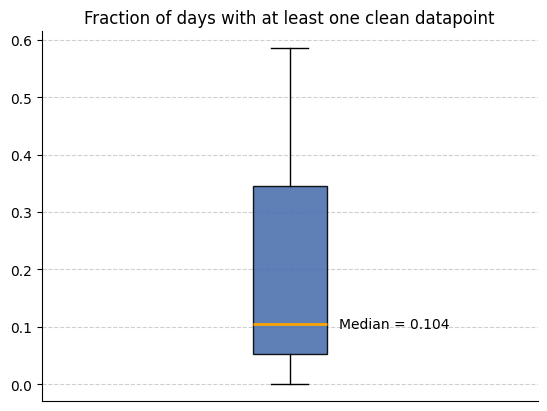

In [12]:
input_folder = output_folder  # The folder that contains all the site subfolders with the cleaned data and metadata features
csv_name = "active_apple_healthkit_heart_rate_h_metadata"
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure=2, site_list=site_list
)
filter_field = "Coverage (secs) from clean datapoints"  # This can be changed if you want coverage from all datapoints

all_participants = []
for path in files_list:
    df = pd.read_csv(path)
    all_participants.append(
        1 - (len(df[df[filter_field] > 1800]) / len(df[filter_field]))
    )

helper_funcs.draw_boxplot(df=all_participants, title="Fraction of days with at least one clean datapoint")